# Descriptive-Title
Felix Zaussinger | XX.YY.ZZZZ

## Core Analysis Goal(s)
1.
2.
3.

## Key Insight(s)
1.
2.
3.

In [151]:
import os
import sys
import logging
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from src import utils, plotting_utils
#import mapping_career_causeways

# OPTIONAL: Load the "autoreload" extension so that code can change
%load_ext autoreload

# OPTIONAL: always reload modules so that as you change code in src, it gets loaded
%autoreload 2

# Settings
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

sns.set_context("talk")
sns.set(rc={'figure.figsize': (6, 3.)})
sns.set_style("ticks")

pd.set_option("display.max_rows", 120)
pd.set_option("display.max_columns", 120)

logging.basicConfig(level=logging.INFO, stream=sys.stdout)

# load paths
useful_paths = utils.UsefulPaths()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


#### Import validated GBN classification file

There are several versions:

Green
- narrow: esco_ess > 0 & (onet_vona | onet_gtp | onet_jrc) > 0
- wide: esco > 0 & (onet_vona | onet_gtp | onet_jrc) > 0

Brown
- narrow: esco_ess > 0 & onet_vona > 0
- wide: esco > 0 & onet_vona > 0
- widest: esco > 0 | onet_vona > 0

Question:
When sorting occupations by ESCO green/brown shares and showing their manual classification status, is there an apparent cutoff in the distribution?

In [152]:
fpath_validated_gbn_classification = r"T:\Documents\Projects\04_jrc_green-skills-regional\02_research\occ_metadata_en_esco_nan_values_filled_selections.xlsx"

dfs = pd.read_excel(
    fpath_validated_gbn_classification,
    sheet_name=None
)

C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\openpyxl\worksheet\_reader.py:312: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


Code ...

In [153]:
dfs.keys()

dict_keys(['validation', 'green_narrow', 'green_wide', 'brown_narrow', 'brown_wide', 'brown_widest'])

Plot
- x-axis: occupations sorted by green/brown shares in 10% bins
- y-axis: manual classification (TRUE/FALSE)

In [154]:
dfs["brown_widest"]

,id,conceptUri,preferredLabel,description,isco_level_4,isco_level_3,isco_level_2,isco_level_1,isco_label_4,isco_label_3,isco_label_2,isco_label_1,gbn_classification_esco,gbn_classification_esco_ess,share_brown_esco,share_brown_esco_ess,share_brown_vona2018,is_brown_eth,classification_felix,is_brown_felix2
0,1318,http://data.europa.eu/esco/occupation/5e748def...,marine fitter,"Marine fitters work primarily in fabrication, ...",7233,723,72,7,Agricultural and industrial machinery mechanic...,Machinery mechanics and repairers,"Metal, machinery and related trades workers",Craft and related trades workers,neutral,neutral,0.153846,0.130435,0.222222,False,NaN,NaN
1,1324,http://data.europa.eu/esco/occupation/f49d893a...,forestry machinery technician,Forestry machinery technicians maintain and tr...,7233,723,72,7,Agricultural and industrial machinery mechanic...,Machinery mechanics and repairers,"Metal, machinery and related trades workers",Craft and related trades workers,neutral,neutral,0.107143,0.157895,0.222222,False,NaN,NaN
2,1316,http://data.europa.eu/esco/occupation/599c2ce9...,forge equipment technician,Forge equipment technicians maintain and repai...,7233,723,72,7,Agricultural and industrial machinery mechanic...,Machinery mechanics and repairers,"Metal, machinery and related trades workers",Craft and related trades workers,neutral,neutral,0.078947,0.142857,0.222222,False,NaN,NaN
3,1322,http://data.europa.eu/esco/occupation/b0480558...,construction equipment technician,"Construction equipment technicians inspect, ma...",7233,723,72,7,Agricultural and industrial machinery mechanic...,Machinery mechanics and repairers,"Metal, machinery and related trades workers",Craft and related trades workers,neutral,neutral,0.071429,0.071429,0.222222,?,NaN,NaN
4,1321,http://data.europa.eu/esco/occupation/955ae83a...,mining equipment mechanic,"Mining equipment mechanics install, remove, ma...",7233,723,72,7,Agricultural and industrial machinery mechanic...,Machinery mechanics and repairers,"Metal, machinery and related trades workers",Craft and related trades workers,neutral,neutral,0.066667,0.000000,0.222222,True,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
912,1305,http://data.europa.eu/esco/occupation/ac160654...,woodturner,Woodturners use a lathe to remove superfluous ...,7523,752,75,7,Woodworking-machine tool setters and operators,"Wood treaters, cabinet-makers and related trad...","Food processing, wood working, garment and oth...",Craft and related trades workers,neutral,neutral,0.071429,0.117647,1.000000,False,NaN,NaN
913,1302,http://data.europa.eu/esco/occupation/77a05858...,wooden furniture machine operator,Wooden furniture machine operators run machine...,7523,752,75,7,Woodworking-machine tool setters and operators,"Wood treaters, cabinet-makers and related trad...","Food processing, wood working, garment and oth...",Craft and related trades workers,neutral,neutral,0.057143,0.000000,1.000000,False,NaN,NaN
914,1304,http://data.europa.eu/esco/occupation/a77bc925...,wood pallet maker,Wood pallet makers create wood pallets for use...,7523,752,75,7,Woodworking-machine tool setters and operators,"Wood treaters, cabinet-makers and related trad...","Food processing, wood working, garment and oth...",Craft and related trades workers,neutral,neutral,0.052632,0.000000,1.000000,False,NaN,NaN
915,1303,http://data.europa.eu/esco/occupation/7e08d38d...,wood boring machine operator,Wood boring machine operators use milling mach...,7523,752,75,7,Woodworking-machine tool setters and operators,"Wood treaters, cabinet-makers and related trad...","Food processing, wood working, garment and oth...",Craft and related trades workers,neutral,neutral,0.048780,0.000000,1.000000,False,NaN,NaN


Brown widest

With stat="percent", all bars sum up to 100. To have the bars belonging to the same x-value summing up to 100, you can use multiple='fill'. Note that in the latter case, the sum is 1.0. The PercentFormatter shows the y-axis as percentages.

Source:
https://stackoverflow.com/questions/70234584/seaborn-how-to-scale-y-axis-to-100-percent-for-each-categorical-value

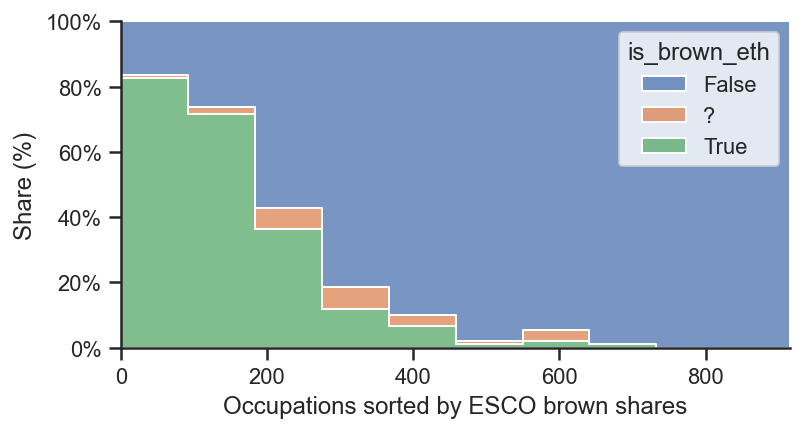

In [162]:
from matplotlib.ticker import PercentFormatter

ds = "brown_widest"
df = dfs[ds].sort_values("share_brown_esco", ascending=False).reset_index()

ax = sns.histplot(
    x=df.index,
    bins=10,
    hue=df.loc[:, "is_brown_eth"],
    hue_order=[False, "?", True],
    element="step",
    stat="percent",
    legend=True,
    multiple="fill",
)

ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_ylabel("Share (%)")
ax.set_xlabel("Occupations sorted by ESCO brown shares")
sns.despine()

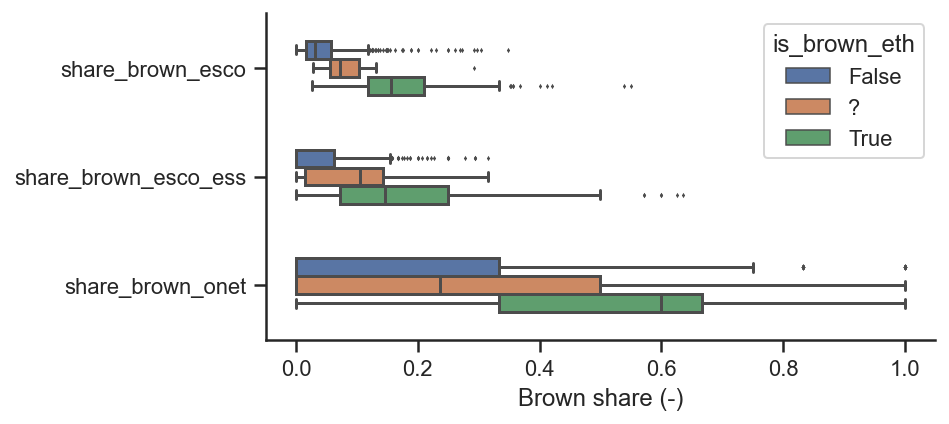

In [163]:
df_long = (
    utils.extract_cols_by_kw(df, "brown")
        .drop(columns=["is_brown_felix2"])
        .rename(columns={"share_brown_vona2018": "share_brown_onet"})
        .melt(id_vars="is_brown_eth")
)

ax = sns.boxplot(
    data=df_long,
    y="variable",
    x="value",
    hue="is_brown_eth",
    hue_order=[False, "?", True],
    orient="h",
    width=0.5,
    fliersize=0.5
)

ax.set_xlabel("Brown share (-)")
ax.set_ylabel(None)
sns.despine()

Brown wide

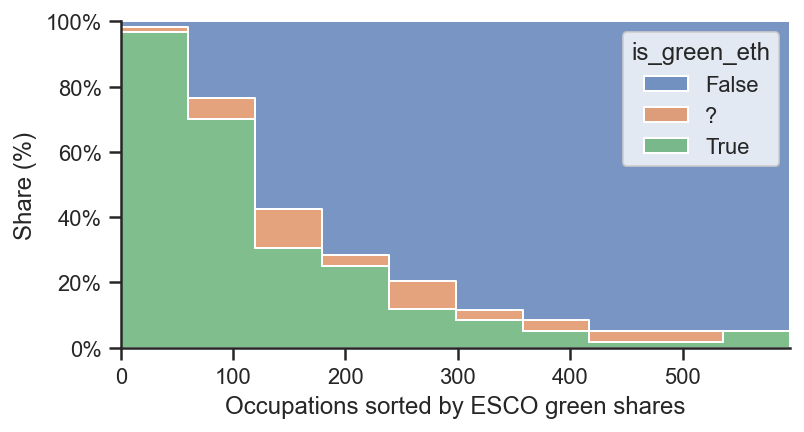

In [165]:
ds = "green_wide"
df = dfs[ds].sort_values("share_green_esco", ascending=False).reset_index()

ax = sns.histplot(
    x=df.index,
    bins=10,
    hue=df.loc[:, "is_green_eth"],
    hue_order=[False, "?", True],
    element="step",
    stat="percent",
    multiple="fill",
    legend=True
)

ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_ylabel("Share (%)")
ax.set_xlabel("Occupations sorted by ESCO green shares")
sns.despine()

In [158]:
df

,index,Unnamed: 0,conceptUri,preferredLabel,description,isco_level_4,isco_level_3,isco_level_2,isco_level_1,isco_label_4,isco_label_3,isco_label_2,isco_label_1,gbn_classification_esco,gbn_classification_esco_ess,share_green_esco,share_green_esco_ess,share_green_gtp,share_green_vona2018,share_green_jrc,is_green_eth
0,0,63,http://data.europa.eu/esco/occupation/bac64fa2...,energy assessor,Energy assessors determine the energy performa...,3112,311,31,3,Civil engineering technicians,Physical and engineering science technicians,Science and engineering associate professionals,Technicians and associate professionals,green,green,0.909091,0.916667,0.000000,0.000000,0.285714,True
1,1,130,http://data.europa.eu/esco/occupation/779d13be...,natural resources consultant,Natural resources consultant provide advice on...,2133,213,21,2,Environmental protection professionals,Life science professionals,Science and engineering professionals,Professionals,green,green,0.787879,1.000000,1.000000,0.000000,0.400000,True
2,2,204,http://data.europa.eu/esco/occupation/114e1eff...,energy conservation officer,Energy conservation officers promote the conse...,3112,311,31,3,Civil engineering technicians,Physical and engineering science technicians,Science and engineering associate professionals,Technicians and associate professionals,green,green,0.750000,0.714286,1.000000,1.000000,0.285714,True
3,3,210,http://data.europa.eu/esco/occupation/ab762f91...,energy analyst,Energy analysts evaluate the consumption of en...,3112,311,31,3,Civil engineering technicians,Physical and engineering science technicians,Science and engineering associate professionals,Technicians and associate professionals,green,green,0.708333,0.681818,1.000000,1.000000,0.285714,True
4,4,216,http://data.europa.eu/esco/occupation/fd4b90ed...,environmental expert,Environmental experts search for technological...,2143,214,21,2,Environmental engineers,Engineering professionals (excluding electrote...,Science and engineering professionals,Professionals,green,green,0.705882,0.863636,1.000000,1.000000,0.111111,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
592,592,2982,http://data.europa.eu/esco/occupation/f272a521...,medical device engineer,Medical device engineers design and develop me...,2152,215,21,2,Electronics engineers,Electrotechnology engineers,Science and engineering professionals,Professionals,neutral,neutral,0.009709,0.000000,0.227273,0.217391,0.000000,False
593,593,2983,http://data.europa.eu/esco/occupation/fb18dfef...,service manager,Service managers are responsible for the super...,1349,134,13,1,Professional services managers not elsewhere c...,Professional services managers,Production and specialised services managers,Managers,neutral,neutral,0.009346,0.076923,0.000000,0.000000,0.100000,False
594,594,2985,http://data.europa.eu/esco/occupation/fb7e2f4f...,mechatronics engineer,Mechatronics engineers design and develop inte...,2144,214,21,2,Mechanical engineers,Engineering professionals (excluding electrote...,Science and engineering professionals,Professionals,neutral,neutral,0.009259,0.000000,0.285714,0.259259,0.000000,False
595,595,3006,http://data.europa.eu/esco/occupation/e1cf6897...,human resources manager,"Human resources managers plan, design and impl...",1212,121,12,1,Human resource managers,Business services and administration managers,Administrative and commercial managers,Managers,neutral,neutral,0.007194,0.000000,0.000000,0.000000,0.066667,False


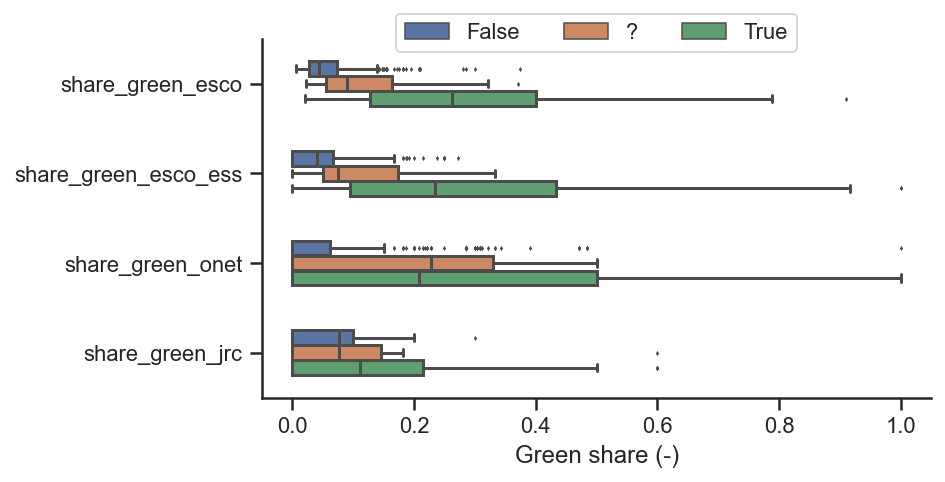

In [166]:
df_long = (
    utils.extract_cols_by_kw(df, "green")
        .drop(columns=["share_green_vona2018"])
        .rename(columns={"share_green_gtp": "share_green_onet"})
        .melt(id_vars="is_green_eth")
)

ax = sns.boxplot(
    data=df_long,
    y="variable",
    x="value",
    hue="is_green_eth",
    hue_order=[False, "?", True],
    orient="h",
    width=0.5,
    fliersize=0.5
)

ax.set_xlabel("Green share (-)")
ax.set_ylabel(None)
plotting_utils.move_legend_to_top(ax, ncol=3, scale=1.1)
sns.despine()